# 12 · Entrenamiento LSTM V4 multianual: prueba técnica con CCA y metodología completa

Este libro **entrena, calibra y evalúa en limpio** el LSTM V4 con 2020–2026,
según `docs/protocolo_lstm_v4_multianual.md` (§5–§7.1). Lo ejecutas tú: por
defecto **no entrena nada** y sólo muestra lo que ya esté guardado.

Los ataques (§7.2) y el daño de red (§8) van en un libro posterior: primero hay
que aceptar que los modelos entrenan bien y son reproducibles.

## Cómo usar este libro

1. Ejecuta todo tal cual (*Run All*). Como no hay modelos todavía, verás
   avisos de «sin resultados»; es normal.
2. En la sección 4 cambia `ENTRENAR = False` → `True` y vuelve a ejecutar
   esa celda. Con `OBJETIVOS = ['CCA']` entrena sólo CCA (prueba técnica,
   unos minutos en CPU).
3. Regresa `ENTRENAR = False` y ejecuta las secciones 5–6 para revisar
   el entrenamiento y la calibración.
4. Sección 7: `VERIFICAR_REPRODUCIBILIDAD = True` entrena CCA **otra vez**
   en una carpeta aparte y compara. Debe salir todo idéntico (regla del CLAUDE.md).
5. Sólo cuando 5–7 te convenzan: sección 8 con `EVALUAR_PRUEBA = True`
   para ver 2024, 2025 y 2026. **Nada de lo que veas ahí puede usarse para
   cambiar parámetros.**
6. Si CCA está bien, en la sección 4 cambia `OBJETIVOS` a la lista de
   elegibles y entrena el resto (≈2–3 h en total, se puede interrumpir y
   reanudar: los objetivos ya guardados se saltan).

### Interruptores (flags)

Un *flag* es una variable `True`/`False` que decide si una celda hace algo
costoso o irreversible. Así *Run All* nunca entrena por accidente.

| Flag | Sección | Qué hace si es `True` |
|---|---|---|
| `ENTRENAR` | 4 | Entrena los objetivos de `OBJETIVOS` que todavía no tienen modelo |
| `SUSTITUIR` | 4 | Permite sobrescribir un modelo ya guardado (déjalo en `False`) |
| `VERIFICAR_REPRODUCIBILIDAD` | 7 | Reentrena en `verificacion/` y compara con el original |
| `EVALUAR_PRUEBA` | 8 | Muestra métricas de 2024–2026 |

### Registro de progreso

Cada vez que una celda entrena, salta un objetivo, falla, verifica o muestra la
prueba, escribe una fila en `results/lstm_v4_multianual_v1/bitacora_entrenamiento.csv`
con fecha y hora, flags, objetivos pedidos y todas las variables del entrenamiento.
**Nunca se borra ni se reescribe**: si cambias `OBJETIVOS`, lo anterior sigue ahí.
La sección 9 muestra esa bitácora, el estado de los 33 objetivos y las notas escritas.

**Mensajes de TensorFlow:** al entrenar pueden salir líneas `E0000 … NodeDef
mentions attribute …` o avisos de CPU. Son avisos internos de TensorFlow, no
errores del notebook.

## 0. Explicación desde cero

Para leer este libro sin saber de redes neuronales.

### ¿Qué etapas se hicieron? (estado al 2026-10-04)

| Etapa | Años | Estado |
|---|---|---|
| Entrenamiento inicial | 2020–2021 | ✅ hecho |
| Validación | 2022 | ✅ hecho |
| Entrenamiento definitivo | 2020–2022 | ✅ hecho |
| Calibración limpia | 2023 | ✅ hecho |
| Prueba principal | 2024 | ⚠️ predicciones calculadas y guardadas, **sin calificar** |
| Evaluación complementaria | 2025 | ⚠️ igual |
| Prueba adicional parcial | 2026 (ene–jul) | ⚠️ igual |

«Sin calificar» = el examen está contestado y en un sobre cerrado. Se abre con la
sección 8 (lecturas limpias) y con el notebook 13 (ataques).

### ¿Qué es el modelo y qué son los pesos?

El modelo es una **fórmula muy grande**: recibe lo que pasó en las 32 vecinas
durante las 24 horas anteriores y devuelve un número, cuánto se va a alejar la
estación de su perfil normal. La fórmula tiene **perillas**: números que multiplican
y suman la información de entrada. Esas perillas son los **pesos**; si cambian, cambia
la respuesta.

- Cada modelo tiene **35 649 pesos**, guardados en `estaciones/<ESTACIÓN>/modelo.keras`.
- Algunos pesos reales de TLI: 0.0966, 0.0945, −0.0374, 0.1468… Están en 7 bloques;
  el primero (66 × 256) recibe las 66 columnas de la ventana.
- Al inicio se ponen **al azar** (siempre el mismo azar: semilla 42) y la fórmula
  responde sin sentido. **Entrenar** = mover las perillas poco a poco hasta que las
  respuestas se parezcan a la realidad.

### ¿Cómo se saca el error?

Funciona porque **el pasado ya tiene la respuesta correcta**: sabemos lo que la
estación midió realmente. Esto se llama aprendizaje supervisado.

1. El modelo recibe la ventana de las 24 h anteriores y **adivina** la corrección.
2. Se compara con la **corrección real** (`lectura − perfil`, conocida porque el
   dato histórico existe).
3. La diferencia es el **error** de ese ejemplo.
4. **Durante el entrenamiento**, después de cada grupo de 64 ejemplos se promedian
   esos errores (al cuadrado) y un procedimiento matemático (el optimizador Adam)
   mueve cada perilla un poquito en la dirección que hace bajar ese promedio.
5. **En la validación (2022) y la calibración (2023)** se hace la misma comparación,
   pero **sin mover las perillas**: sólo se mide qué tan bien le va con datos que no vio.

Ejemplo (CCA, 10/may/2023 15:00): perfil 77.1 ppb, corrección adivinada −31.2 →
predicción 45.9 ppb. Lectura real 43 ppb. Error = 43 − 45.9 = **−2.9 ppb**.

### Ejemplos, batches y épocas: la analogía del cuaderno de ejercicios

- **Ejemplo:** un ejercicio con su respuesta («esto pasó en las vecinas → TLI se
  alejó tanto de su perfil»). TLI tiene 7 220 de 2020–2021.
- **Batch:** se resuelven 64 ejercicios, se comparan con las respuestas y se corrige
  un poco el método (los pesos). Luego los siguientes 64.
- **Época:** **una pasada completa por todo el cuaderno**. Dos épocas = el cuaderno
  revisado dos veces.
- Al terminar cada época se pone un **examen con ejercicios que nunca vio** (2022).
  En el examen no se corrige nada; sólo se mide.

### ¿Qué significa un error de 140.8?

Es una calificación de error (más bajo = mejor), el **promedio de los errores al
cuadrado** (MSE). Ejemplo con tres errores de 10, −12 y 8 ppb: al cuadrado 100, 144 y
64; promedio **102.7** «ppb²». Se elevan al cuadrado para que los errores positivos y
negativos no se cancelen.

Para volver a ppb se saca **raíz cuadrada**: √140.8 ≈ **11.9 ppb**, «se equivoca unos 12 ppb».

| Calificación (ppb²) | Raíz (ppb) |
|---:|---:|
| 46.4 | 6.8 |
| 112.2 | 10.6 |
| 140.8 | 11.9 |
| 144.3 | 12.0 |
| 179.5 | 13.4 |

### Sobreajuste: por qué E fue tan pequeño

En TLI, después de la 2.ª pasada el error en los ejercicios que repite siguió bajando
(de ~12 a ~7 ppb) pero en el examen nuevo de 2022 **subió** (de ~12 a ~13 ppb): ya no
aprendía, **memorizaba** las respuestas de 2020–2021. Por eso E = 2: las pasadas antes
de empezar a memorizar. El modelo definitivo se entrena desde cero 2 pasadas sobre
2020–2022.

### Calibración y umbral

El modelo definitivo predijo cada hora de 2023 (que tampoco vio) y se midió cuánto se
equivoca normalmente. En TLI, el 95 % de las veces se equivocó menos de **21.16 ppb**:
ése es el **umbral**. Si una lectura se aleja de lo esperado más que eso, se sospecha
de un ataque.


## 1. Glosario mínimo

| Término | Qué significa aquí |
|---|---|
| **Modelo / red neuronal** | Una función con muchos números ajustables que recibe la ventana de 24 h de las vecinas y devuelve una estimación de la estación objetivo. |
| **Pesos** | Esos números ajustables (≈35 600 en este LSTM). «Entrenar» es buscar los pesos que hacen que la estimación se parezca a la lectura real. Se guardan en `modelo.keras`. |
| **LSTM** | Tipo de red que lee la ventana hora por hora y conserva una «memoria» de lo que vio antes; útil para series de tiempo. Aquí tiene 64 unidades (tamaño de esa memoria). |
| **Ejemplo** | Un par (entrada, respuesta): la ventana 24 × 66 y la desviación real de la estación objetivo a la hora t. |
| **Época** | Una pasada completa por todos los ejemplos de entrenamiento. |
| **Batch** | Grupo de 64 ejemplos. Los pesos se corrigen después de cada batch, no después de cada ejemplo. |
| **`shuffle=True`** | En cada época los batches se presentan en orden revuelto (con la semilla 42), para que ningún mes quede siempre al final. No mezcla etapas. |
| **Pérdida (`loss`, MSE)** | Promedio del error al cuadrado en el entrenamiento, en ppb². Baja conforme el modelo aprende. |
| **`val_loss`** | La misma pérdida, pero sobre 2022, que el modelo **no** usa para ajustar pesos. Dice si lo aprendido sirve para datos nuevos. |
| **Sobreajuste** | Cuando `loss` sigue bajando pero `val_loss` sube: el modelo memoriza 2020–2021 en vez de aprender patrones generales. |
| **EarlyStopping** | Detiene la fase 1 si `val_loss` no mejora en 8 épocas seguidas (paciencia 8). |
| **E** | La época con menor `val_loss`. Es el «número de vueltas» que se usa al reentrenar con 2020–2022. |
| **Semilla 42** | Fija el azar (pesos iniciales, dropout, orden de batches) para que dos corridas den lo mismo. |
| **Dropout 0.2** | Durante el entrenamiento apaga al azar el 20 % de las conexiones; reduce el sobreajuste. |
| **Normalización** | Restar la media y dividir entre la desviación de cada estación (calculadas con el ajuste), para que todas queden en escala parecida. |
| **Máscara** | Por cada vecina y hora: 1 si hubo dato, 0 si faltó. El 0 de relleno del valor no significa 0 ppb. |
| **Seno/coseno de la hora** | La hora del día como punto en un círculo: así 23:00 y 00:00 quedan juntas. **No es la zona horaria.** |
| **Perfil (base)** | Promedio de la estación objetivo a esa hora en los 14 días anteriores. El modelo sólo aprende la **corrección** sobre ese perfil. |
| **Predicción** | `base + corrección aprendida`. |
| **Residuo** | `lectura − predicción`. Un ataque grande produce un residuo grande. |
| **p95 (umbral)** | El valor que deja por debajo al 95 % de los residuos absolutos limpios de 2023. Alerta si `|residuo| > p95`. |
| **Falsa alarma** | Alerta sobre una lectura limpia (sin ataque). |

## 2. Cómo se entrenó tu V4 de CCA (2025) y qué cambia ahora

Antes de entrenar nada nuevo, verifico con los artefactos guardados cómo era el
V4 que ya aceptaste (`notebooks/07_multiestacion.ipynb`, celda del modelo 4,
`results/modelo4_lstm.keras`). Esta sección sólo **carga**; no entrena.

In [19]:
import json, sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
warnings.filterwarnings('ignore', category=UserWarning)

from src.detect import multianual as m
from src.detect import entrenamiento_multianual as em
from src.detect.windows import construir_ventanas
from src.ingest.rama import load_wide, to_long

pd.set_option('display.width', 200)
SAL = RAIZ / 'results/lstm_v4_multianual_v1'
EST = SAL / 'estaciones'
VER = SAL / 'verificacion'
IMG = RAIZ / 'docs/img/lstm_v4_multianual_v1'
BITACORA = SAL / 'bitacora_entrenamiento.csv'   # registro de cada acción (sección 9)

In [20]:
from tensorflow import keras

meta = json.loads((RAIZ / 'results/metadatos_modelo4_cca.json').read_text())
modelo4 = keras.models.load_model(RAIZ / 'results/modelo4_lstm.keras', compile=False)
with np.load(RAIZ / 'results/preprocesamiento_modelo4_cca.npz', allow_pickle=False) as pre:
    vecinas4 = pre['vecinas'].tolist()
    corte4 = int(pre['corte'])
    ts4 = pd.DatetimeIndex(pre['timestamps'])

print('Entrada del modelo V4 guardado:', modelo4.input_shape, '→ (ejemplos, 24 horas, 66 características)')
print('Pesos ajustables:', f'{modelo4.count_params():,}')
print('Vecinas:', len(vecinas4), '| CCA entre las entradas:', 'CCA' in vecinas4)
print(f'Split 80/20 por filas: corte en la fila {corte4} = {ts4[corte4]}  (train hasta {ts4[corte4 - 1]})')
print('Épocas ejecutadas:', meta['epocas_ejecutadas'], 'de', meta['epocas_max'],
      '| validación interna:', meta['val_frac'], '| p95:', round(meta['umbral_p95_ppb'], 2), 'ppb')
modelo4.summary()

Entrada del modelo V4 guardado: (None, 24, 66) → (ejemplos, 24 horas, 66 características)
Pesos ajustables: 35,649
Vecinas: 32 | CCA entre las entradas: False
Split 80/20 por filas: corte en la fila 7008 = 2025-10-20 00:00:00  (train hasta 2025-10-19 23:00:00)
Épocas ejecutadas: 30 de 60 | validación interna: 0.2 | p95: 14.75 ppb


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        33,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,649 (139.25 KB)

 Trainable params: 35,649 (139.25 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Una ventana real del V4, construida con la misma función de 2025, para ver seno y coseno.
mat25 = (to_long(load_wide(RAIZ / 'data/raw/2025O3.xls'), 'O3')
         .pivot(index='timestamp', columns='station', values='value').dropna(axis=1, how='all'))
X25, *_ = construir_ventanas(mat25.iloc[:200], 'CCA', ventana=24)
ventana = pd.DataFrame(X25[0], index=mat25.index[0:24], columns=[f'{c}_valor' for c in vecinas4]
                       + [f'{c}_mascara' for c in vecinas4] + ['hora_sin', 'hora_cos'])
print('Primera ventana del V4 (24 filas = 24 horas de contexto; objetivo:', mat25.index[24], ')')
print(ventana[['ACO_valor', 'ACO_mascara', 'hora_sin', 'hora_cos']].round(3).assign(hora=ventana.index.hour).to_string())

Primera ventana del V4 (24 filas = 24 horas de contexto; objetivo: 2025-01-02 00:00:00 )
                     ACO_valor  ACO_mascara  hora_sin  hora_cos  hora
timestamp                                                            
2025-01-01 00:00:00        0.0          0.0     0.000     1.000     0
2025-01-01 01:00:00        0.0          0.0     0.259     0.966     1
2025-01-01 02:00:00        0.0          0.0     0.500     0.866     2
2025-01-01 03:00:00        0.0          0.0     0.707     0.707     3
2025-01-01 04:00:00        0.0          0.0     0.866     0.500     4
2025-01-01 05:00:00        0.0          0.0     0.966     0.259     5
2025-01-01 06:00:00        0.0          0.0     1.000     0.000     6
2025-01-01 07:00:00        0.0          0.0     0.966    -0.259     7
2025-01-01 08:00:00        0.0          0.0     0.866    -0.500     8
2025-01-01 09:00:00        0.0          0.0     0.707    -0.707     9
2025-01-01 10:00:00        0.0          0.0     0.500    -0.866    10
2

**Lo que se comprueba arriba:**

- El V4 recibe **24 horas × 66 características**: 32 vecinas normalizadas, sus
  32 máscaras y 2 columnas de hora. CCA **no** está entre sus entradas.
- `hora_sin` y `hora_cos` son la hora de **cada fila del contexto**: en la
  fila de las 00:00, seno 0 y coseno 1; a las 06:00, seno 1 y coseno 0; y así
  hasta cerrar el círculo. El modelo deduce la hora objetivo porque siempre es
  la hora siguiente a la última fila. No interviene la zona horaria: las
  horas son las del archivo SIMAT (convención provisional `HORA=1 → 00:00`).
- El modelo aprende la **desviación respecto al perfil de 14 días**, no el
  valor absoluto.

### V4 2025 frente a V4 multianual

| Aspecto | V4 CCA 2025 (aceptado) | V4 multianual (este libro) | ¿Por qué cambia? |
|---|---|---|---|
| Datos | 2025, 8 760 h | 2020 – jul 2026, 57 696 h | más años y temporada alta en prueba |
| Columnas | las que no estaban vacías en 2025 (33) | las mismas 33, fijas todos los años | otro año daría otro número de columnas |
| Entrada | 24 × 66, sin/cos por fila | **idéntica** (probado en `tests/test_entrenamiento_multianual.py`) | — |
| Arquitectura | LSTM 64, dropout 0.2, densa 32, salida 1 | **idéntica** (`construir_modelo`) | — |
| Optimizador, batch, semilla | Adam 0.001, 64, 42 | idénticos | — |
| Separación | 80/20 por filas; validación = último 20 % del train | por años: 2020–21 / 2022 / 2023 / 2024–26 | etapas independientes y estaciones completas |
| Épocas | EarlyStopping dentro del mismo entrenamiento (30) | fase 1 elige E con 2022; fase 2 reentrena 2020–22 E épocas | el modelo final también aprende de 2022 |
| `shuffle` | `True` (valor por defecto de Keras) | `True`, explícito | — |
| Perfil, respaldo de arranque | media global de **toda** la serie (no causal) | media histórica **anterior a t** | evitar información del futuro |
| Contexto en el corte | se descartaban las primeras 24 h del test | se usa el contexto de la etapa anterior | no perder ejemplos |
| Canal sin historia | no aplicaba | XAL oculto (valor 0, máscara 0) | sus pesos no se entrenarían |
| Umbral | p95 del train (14.75) y operativo 22.6 | p95 propio de 2023 por estación | calibrar fuera del entrenamiento |

Los números del V4 de 2025 **no** se comparan uno a uno con los de este libro:
son otro periodo, otro protocolo y otro umbral.

### ¿Es el mismo V4? ¿Dónde están la ventana y el perfil adaptativo?

**Sí, es el V4:** misma entrada, mismo perfil adaptativo de 14 días, misma red y
misma forma de detectar. Lo que cambia es **con qué datos** y **cómo se separan**
(tabla de arriba). Dónde vive cada pieza:

| Pieza del V4 | V4 2025 (notebook 07) | V4 multianual (este libro) | Se ve en |
|---|---|---|---|
| **Ventana 24 h** de 32 vecinas + máscaras + seno/coseno | `src/detect/windows.py::construir_ventanas` | `src/detect/entrenamiento_multianual.py::caracteristicas` (las 66 columnas por hora) y `::tensores` (toma t−24 … t−1 para cada objetivo) | ejemplos reales 24 × 66 en `results/lstm_v4_multianual_v1/ejemplos_etapas/*_entrada_24x66.csv` (notebook 11) |
| **Perfil adaptativo** (media de la misma hora en los 14 días previos) | `src/detect/windows.py::perfil_adaptativo` | `src/detect/multianual.py::perfil_causal` (misma media móvil; sólo cambia el respaldo cuando no hay datos en esos 14 días) | columna `base_ppb` y `origen_base` de cada `calibracion_2023.csv.gz` / `predicciones_*.csv.gz` |
| Predecir la **desviación** respecto al perfil | `predecir_desviacion=True` | `y = original − base` en `::tensores` | `correccion_ppb` en los mismos CSV |
| Red LSTM 64 → dropout 0.2 → densa 32 → salida | `src/detect/lstm.py::construir_modelo` | la **misma función** | `modelo.keras` |
| Semilla 42 antes de construir | `fijar_semilla(42)` | la misma, dentro de `::nuevo_modelo` | `configuracion.json` |
| Detector `|lectura − predicción| > umbral` | p95 del train / 22.6 operativo | p95 de 2023 por estación | `umbral_p95_cal2023.txt` |

Que la ventana sea **idéntica** no es una suposición: `tests/test_entrenamiento_multianual.py`
construye las mismas horas con `construir_ventanas` del V4 y con el código nuevo y
comprueba que los 24 × 66 números coinciden exactamente.


## 3. Base temporal común

Carga la matriz y las normalizaciones construidas en el notebook 11. Tarda unos segundos.

In [22]:
ctx = em.contexto(RAIZ)
cob = pd.read_csv(SAL / 'cobertura_etapas.csv')
clases = cob.drop_duplicates('objetivo').set_index('objetivo')[['clasificacion', 'motivo']]
ELEGIBLES = [s for s in m.ESTACIONES if clases.at[s, 'clasificacion'] != 'fuera']
print('Matriz:', ctx['valores'].shape, '| canales inactivos:', ctx['definitiva']['inactivos'])
print(f'Elegibles ({len(ELEGIBLES)}):', ' '.join(ELEGIBLES))
print('Fuera:', clases.index[clases.clasificacion == 'fuera'].tolist())
print('Baja representatividad (se entrenan, se reportan aparte):',
      clases.index[clases.clasificacion == 'baja_representatividad'].tolist())

Matriz: (57696, 33) | canales inactivos: ['XAL']
Elegibles (31): ACO AJM AJU ATI BJU CAM CCA CHO CUA CUT FAC FAR GAM INN IZT LLA LPR MER MGH MON MPA NEZ PED SAC SAG TAH TLA TLI UAX UIZ VIF
Fuera: ['HGM', 'XAL']
Baja representatividad (se entrenan, se reportan aparte): ['AJM', 'INN', 'TLI']


## 4. Entrenamiento

**Qué pasa por cada objetivo cuando `ENTRENAR = True`:**

1. **Fase 1, selección.** Modelo nuevo con semilla 42; entrena con 2020–2021 y
   después de cada época mide `val_loss` en 2022. EarlyStopping lo detiene si
   en 8 épocas no mejora. Se elige **E** = época con menor `val_loss`.
2. **Fase 2, definitivo.** Otro modelo nuevo, otra vez semilla 42, normalización
   recalculada con 2020–2022; entrena **exactamente E épocas** con 2020–2022,
   sin validación. Este es el modelo que se guarda (`modelo.keras`).
3. **Calibración.** Se recarga el modelo desde disco y se predice 2023 → p95.
4. **Predicción limpia.** Mismo modelo, mismo umbral, sobre 2024, 2025 y 2026.

Si un objetivo ya tiene `modelo.keras`, se salta (no se reentrena ni sobrescribe).
Para CCA espera ≈5 s por época y fase.

In [23]:
# Corrida 2026-10-03 23:30–23:49: ENTRENAR=True, OBJETIVOS=ELEGIBLES, VERBOSE=1 (30 entrenados, 0 errores;
# ver bitácora, sección 9). Las salidas de abajo son de esa corrida. Se regresa a False para no repetir.
ENTRENAR = False          # ← cambia a True para entrenar
SUSTITUIR = False         # ← déjalo en False: no sobrescribir modelos guardados
OBJETIVOS = ELEGIBLES       # prueba técnica; después: OBJETIVOS = ELEGIBLES
VERBOSE = 1               # 1 = muestra una barra por época; 0 = silencioso

import time
FLAGS = dict(ENTRENAR=ENTRENAR, SUSTITUIR=SUSTITUIR, OBJETIVOS=OBJETIVOS)
if ENTRENAR:
    errores = []
    for i, obj in enumerate(OBJETIVOS, 1):
        carpeta = EST / obj
        flags = dict(FLAGS, clasificacion=clases.at[obj, 'clasificacion'])
        if (carpeta / 'modelo.keras').exists() and not SUSTITUIR:
            print(f'{i:02d}/{len(OBJETIVOS)} {obj}: ya entrenado, se salta.')
            em.registrar(BITACORA, 'entrenar', obj, 'saltado_ya_existe', flags=flags, carpeta=carpeta,
                         config=json.loads((carpeta / 'configuracion.json').read_text()))
            continue
        if clases.at[obj, 'clasificacion'] == 'fuera':
            print(f'{i:02d}/{len(OBJETIVOS)} {obj}: fuera del protocolo ({clases.at[obj, "motivo"]}).')
            em.registrar(BITACORA, 'entrenar', obj, 'fuera_del_protocolo', clases.at[obj, 'motivo'], flags=flags)
            continue
        t0 = time.time()
        try:
            cfg = em.entrenar_objetivo(ctx, obj, carpeta, sustituir=SUSTITUIR, verbose=VERBOSE)
        except Exception as e:                       # se registra y se sigue con el siguiente
            errores.append(obj)
            print(f'{i:02d}/{len(OBJETIVOS)} {obj}: ERROR {type(e).__name__}: {e}')
            em.registrar(BITACORA, 'entrenar', obj, 'error', f'{type(e).__name__}: {e}', flags=flags,
                         carpeta=carpeta, segundos=time.time() - t0)
            continue
        em.registrar(BITACORA, 'entrenar', obj, 'entrenado', flags=flags, config=cfg, carpeta=carpeta,
                     segundos=time.time() - t0)
        print(f'{i:02d}/{len(OBJETIVOS)} {obj}: E={cfg["epoca_E"]}, p95={cfg["umbral_p95_ppb"]:.2f} ppb, '
              f'{time.time() - t0:.0f} s', flush=True)
    if errores:
        print('\nObjetivos con error (ver bitácora):', errores)
else:
    print('ENTRENAR = False: no se entrena. Objetivos ya guardados:',
          sorted(p.parent.name for p in EST.glob('*/modelo.keras')) or 'ninguno')

Epoch 1/60


E0000 00:00:1791091767.837016  289999 node_def_util.cc:684] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 77.6598 - mae: 6.4929 - val_loss: 112.8478 - val_mae: 7.7902
Epoch 2/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 63.3365 - mae: 5.8798 - val_loss: 100.2062 - val_mae: 7.3982
Epoch 3/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 51.9207 - mae: 5.3927 - val_loss: 98.1455 - val_mae: 7.2899
Epoch 4/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 45.7031 - mae: 5.0527 - val_loss: 95.5790 - val_mae: 7.2252
Epoch 5/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 40.7166 - mae: 4.7784 - val_loss: 95.3601 - val_mae: 7.1961
Epoch 6/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 36.8163 - mae: 4.5647 - val_loss: 95.4855 - val_mae: 7.2292
Epoch 7/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 33.9810 - mae: 4.3939 - val_loss: 97.3140 - val_mae: 7.2972
Epoch 8/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 31.8361 - mae: 4.2612 - val_loss: 96.4432 - val_mae: 7.2797
Epoch 9/60
104/104 ━━━━━━━━━━━━━━━━━━━━ 1

E0000 00:00:1791091791.096511  289999 node_def_util.cc:684] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 91.4995 - mae: 7.0170
Epoch 2/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 67.1317 - mae: 6.0880
Epoch 3/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 56.3971 - mae: 5.5867
Epoch 4/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 51.2635 - mae: 5.3276
Epoch 5/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 47.4493 - mae: 5.1398
Epoch 6/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 43.8837 - mae: 4.9539
Epoch 7/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 40.8612 - mae: 4.7640
Epoch 8/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 38.7455 - mae: 4.6529
Epoch 9/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 36.8641 - mae: 4.5440
Epoch 10/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 34.8308 - mae: 4.4014
Epoch 11/11
210/210 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 33.3004 - mae: 4.3278


...

30/31 UIZ: E=1, p95=25.13 ppb, 26 s
Epoch 1/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 105.8816 - mae: 7.5344 - val_loss: 104.0897 - val_mae: 7.3837
Epoch 2/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 70.9008 - mae: 6.2222 - val_loss: 103.3539 - val_mae: 7.2688
Epoch 3/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 60.5422 - mae: 5.7517 - val_loss: 104.1641 - val_mae: 7.2695
Epoch 4/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 54.4645 - mae: 5.4697 - val_loss: 101.2227 - val_mae: 7.2574
Epoch 5/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 50.4788 - mae: 5.2754 - val_loss: 101.1095 - val_mae: 7.2197
Epoch 6/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 47.7318 - mae: 5.1255 - val_loss: 107.9215 - val_mae: 7.4350
Epoch 7/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 45.0423 - mae: 4.9906 - val_loss: 106.9649 - val_mae: 7.3986
Epoch 8/60
222/222 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 43.1783 - mae: 4.8901 - val_loss: 107.7032 - val_mae: 7

E0000 00:00:1791092929.761981  289999 node_def_util.cc:684] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


347/347 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 100.3992 - mae: 7.3452
Epoch 2/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 70.1696 - mae: 6.2155
Epoch 3/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 61.0244 - mae: 5.7981
Epoch 4/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 55.3462 - mae: 5.5085
Epoch 5/5
347/347 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 51.6839 - mae: 5.3442


E0000 00:00:1791092944.125695  289999 node_def_util.cc:684] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


31/31 VIF: E=5, p95=20.62 ppb, 45 s


## 5. Revisión del entrenamiento (sin mirar la prueba)

**Cómo leer las curvas:**

- Izquierda, **fase 1**. `loss` (entrenamiento) debe bajar. `val_loss` (2022)
  baja al principio y luego se estabiliza o sube. La línea vertical es **E**.
  Si `val_loss` sube mucho después de E, hubo sobreajuste y EarlyStopping hizo
  su trabajo. Si E es la última época posible (60), el modelo quizá seguía
  aprendiendo: anótalo, no lo cambies.
- Derecha, **fase 2**. Sólo `loss`, durante E épocas: debe bajar de forma
  parecida a la fase 1. No hay `val_loss` porque 2022 ya es parte del ajuste.
- `loss` está en ppb² (MSE de la desviación); su raíz da una idea del error típico en ppb.

### De dónde sale cada número de esta sección

| Número | Archivo | Cómo se calcula | Qué significa |
|---|---|---|---|
| `loss` | `seleccion/historia_seleccion.csv`, `historia_definitiva.csv` | Keras, al final de cada época: promedio de `(desviación real − corrección predicha)²` sobre los ejemplos de **entrenamiento** | Qué tan bien reproduce lo que está aprendiendo. Siempre baja; por sí solo no dice si generaliza. |
| `mae` | mismos archivos | promedio de `|desviación real − corrección predicha|` en entrenamiento | Lo mismo en ppb, más fácil de leer que el MSE. |
| `val_loss`, `val_mae` | `historia_seleccion.csv` | igual que `loss`/`mae`, pero sobre **2022**, sin ajustar pesos con esos ejemplos | La señal honesta: si baja, lo aprendido sirve para un año que el modelo no vio. |
| `E` (`epoca_E`) | `configuracion.json` | `argmin(val_loss) + 1` (primera época con el mínimo) | Cuántas épocas se repiten en la fase 2. |
| `epocas_seleccion_ejecutadas` | `configuracion.json` | E + las épocas que esperó EarlyStopping (≤ 8) | Si es 60 y E también, el modelo no había terminado de mejorar. |
| `n_ajuste_inicial`, `n_validacion`, … | `configuracion.json` | número de ejemplos efectivos de cada etapa (objetivo válido, base disponible) | Cuántos datos hubo en cada etapa; debe coincidir con `cobertura_etapas.csv`. |

**Una brecha grande entre `loss` y `val_loss`** (entrenamiento mucho mejor que 2022)
indica sobreajuste o que los años son distintos entre sí (deriva). E pequeño
significa que la parte útil se aprende en pocas épocas.

### Recorrido de un entrenamiento real, paso a paso (TLI)

Esto es lo que hizo la celda de la sección 4 con **un** objetivo; con los 30 se repite igual.
Números de `estaciones/TLI/` (historia y `configuracion.json`).

**Paso 0. Preparar los ejemplos.** Para cada hora t en que TLI tiene lectura y hay
perfil disponible se arma un ejemplo:

- *entrada*: las 24 horas anteriores (t−24 … t−1) de las otras 32 estaciones,
  ya normalizadas, con sus máscaras y la hora en seno/coseno → una tabla 24 × 66
  (ésa es **la ventana**);
- *respuesta esperada*: `lectura de TLI en t − perfil de TLI en t` (el perfil es
  el promedio de TLI a esa misma hora en los 14 días anteriores: **el perfil adaptativo**).

TLI tiene 7 220 ejemplos en 2020–2021, 4 598 en 2022 y 1 509 en 2023.

**Paso 1. Fase 1: aprender con 2020–2021 y vigilar con 2022.** Se crea una red con
pesos al azar (pero siempre los mismos, semilla 42). En cada época revisa los 7 220
ejemplos en batches de 64 y corrige sus pesos para que la corrección predicha se
acerque a la real. Al final de cada época se mide el error en 2022 sin corregir nada:

| Época | `loss` 2020–21 (ppb²) | `val_loss` 2022 (ppb²) | Lectura |
|---:|---:|---:|---|
| 1 | 140.8 | 145.5 | empieza a aprender |
| 2 | 112.2 | **144.3** | mejor resultado en 2022 → **E = 2** |
| 3 | 88.5 | 145.3 | 2020–21 sigue mejorando, 2022 ya no |
| 4–10 | 74 → 46 | 171 → 179 (máx. 185) | memoriza 2020–21; en 2022 empeora |

EarlyStopping esperó 8 épocas sin mejora (3 a 10) y detuvo la fase 1 en la 10.
La raíz de 144.3 ≈ 12 ppb: el error típico en 2022.

**Paso 2. Fase 2: modelo definitivo.** Se descarta el modelo de la fase 1. Se crea
otro desde cero (misma semilla) y se entrena con 2020–2022 juntos (11 818
ejemplos) exactamente 2 épocas. Así el modelo final también aprende de 2022,
pero sin pasar del punto donde dejaba de generalizar. Se guarda como `modelo.keras`.

**Paso 3. Calibración.** Se carga `modelo.keras` desde disco y se predice cada hora
de 2023: `predicción = perfil + corrección`. Con los 1 509 residuos
`|lectura − predicción|` se toma el percentil 95 → **umbral = 21.16 ppb**.

**Paso 4. Predicción limpia de 2024–2026.** Mismo modelo y mismo umbral, sin
reentrenar. Se guardan, pero no se miran hasta la sección 8.

**Paso 5. Verificación.** Se repitieron los pasos 1–4 en otra carpeta y todo salió
idéntico: con la misma semilla, los mismos datos y el mismo entorno, el
entrenamiento es determinista.

**Un ejemplo real (CCA, 10/may/2023 15:00):** el perfil de 14 días decía 77.1 ppb
(promedio de las lecturas de las 15:00 del 26/abr al 9/may: 76, 63, 71, 68, 73, 66,
62, 101, 118, 97, 93, 100, 34, 58). La lectura real fue 43 ppb. Con el perfil solo,
el residuo habría sido −34 ppb, por encima del umbral de 24.2: **falsa alarma**. El
LSTM vio en las vecinas de las 24 h previas que ese día venía más bajo y predijo
una corrección de −31.2 → predicción 45.9 ppb, residuo −2.9: sin alarma. Esto es
exactamente lo que aporta el LSTM sobre el perfil.

*Detalle honesto:* la predicción puede quedar ligeramente negativa en horas de
ozono casi cero (CCA, 1/ene/2023 00:00: −0.02 ppb), porque la salida del modelo
no está acotada. Para el detector sólo importa el residuo.


CCA: E = 2 de 10 épocas ejecutadas en la fase 1 (máximo 60).
Ejemplos — ajuste inicial 16,184 · validación 8,342 · ajuste definitivo 24,526 · calibración 8,156
val_loss mínimo 154.0 ppb² → raíz ≈ 12.4 ppb


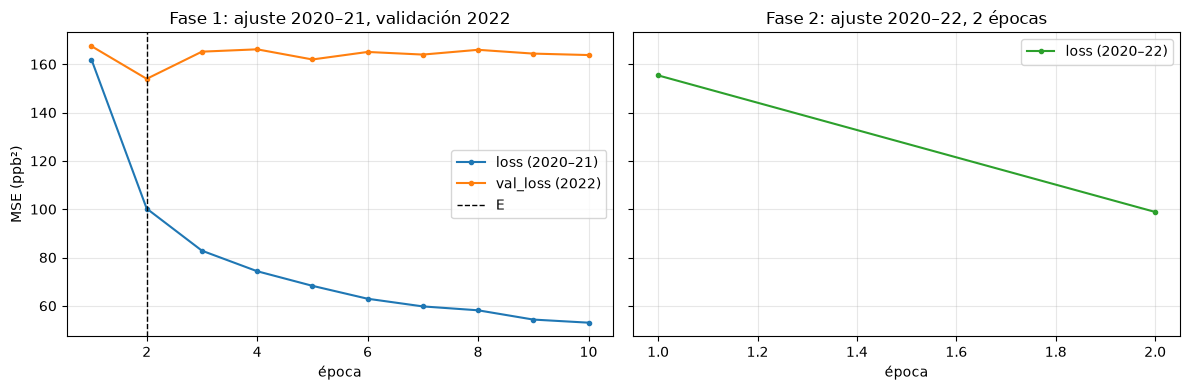

In [24]:
REVISAR = 'CCA'
res = em.cargar_objetivo(EST / REVISAR)
if res is None:
    print(f'{REVISAR}: sin resultados todavía (entrena en la sección 4).')
else:
    cfg = res['config']
    print(f"{REVISAR}: E = {cfg['epoca_E']} de {cfg['epocas_seleccion_ejecutadas']} épocas ejecutadas en la fase 1 "
          f"(máximo {cfg['max_epocas']}).")
    print(f"Ejemplos — ajuste inicial {cfg['n_ajuste_inicial']:,} · validación {cfg['n_validacion']:,} · "
          f"ajuste definitivo {cfg['n_ajuste_definitivo']:,} · calibración {cfg['n_calibracion']:,}")
    print(f"val_loss mínimo {cfg['val_loss_minimo']:.1f} ppb² → raíz ≈ {np.sqrt(cfg['val_loss_minimo']):.1f} ppb")
    fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
    res['seleccion'][['loss', 'val_loss']].plot(ax=ax[0], marker='.')
    ax[0].axvline(cfg['epoca_E'], color='k', ls='--', lw=1, label=f"E = {cfg['epoca_E']}")
    ax[0].set_title('Fase 1: ajuste 2020–21, validación 2022'); ax[0].legend(['loss (2020–21)', 'val_loss (2022)', 'E'])
    res['definitiva'][['loss']].plot(ax=ax[1], marker='.', color='C2')
    ax[1].set_title(f'Fase 2: ajuste 2020–22, {cfg["epoca_E"]} épocas'); ax[1].legend(['loss (2020–22)'])
    for a in ax:
        a.set_xlabel('época'); a.set_ylabel('MSE (ppb²)'); a.grid(alpha=.3)
    fig.tight_layout(); plt.show()

## 6. Calibración 2023

El p95 se calcula con los residuos absolutos de 2023, que el modelo nunca vio al
entrenar. Se muestran también por mes para ver si 2023 tiene meses poco
representados (en TLI e INN hay pocos datos de calibración).

`mae_solo_perfil` es el error que tendrías **sin** LSTM, usando sólo el perfil de
14 días. Si el LSTM no lo mejora, la corrección aprendida no está aportando.

### De dónde sale cada métrica (sección 6 y sección 8)

Todas salen de los archivos `calibracion_2023.csv.gz` o `predicciones_<año>.csv.gz`
del objetivo, calculadas con `em.metricas_limpias`. En cada fila hay una lectura
limpia (sin ataque): `original_ppb` (lo que midió la estación), `base_ppb` (perfil
de 14 días), `predicho_ppb` (base + corrección del LSTM) y
`residuo_ppb = original − predicho`.

| Métrica | Fórmula | Unidad | Cómo leerla |
|---|---|---|---|
| `n` | número de filas | lecturas | Cuántas lecturas válidas se evaluaron. |
| `mae` | promedio de `|residuo|` | ppb | Error típico **sin signo**: «en promedio me equivoco por tantos ppb». Menor es mejor. |
| `sesgo` | promedio de `residuo` (con signo) | ppb | Si se equivoca más hacia un lado. **+** = el modelo **subestima** (la lectura real suele ser mayor); **−** = sobreestima. Cerca de 0 es bueno, pero puede ocultar sesgos opuestos que se cancelan (ver la tabla por hora). |
| `sigma` | desviación estándar de `residuo` (`ddof=0`) | ppb | Ancho del error alrededor del sesgo. Con errores aproximadamente normales, ≈68 % cae dentro de ±1 sigma y ≈95 % dentro de ±2. |
| RMSE | raíz del promedio de `residuo²` | ppb | Como el MAE, pero castiga más los errores grandes. ≈ √(sesgo² + sigma²). |
| `umbral` (p95) | percentil 95 de `|residuo|` en **2023** | ppb | El 95 % de las lecturas limpias de 2023 tiene un error menor. Es el corte del detector: alerta si `|residuo| > umbral`. |
| `falsas_alarmas` | cuántas lecturas limpias tienen `|residuo| > umbral` | lecturas | Alertas sin ataque. |
| `fpr` | `falsas_alarmas / n` | fracción | Tasa de falsas alarmas. En 2023 es ≈0.05 **por construcción** (así se eligió el p95); en otros años es lo que hay que medir. |
| `mae_solo_perfil`, `sesgo_solo_perfil` | igual, con `original − base` | ppb | El mismo error si no hubiera LSTM. La diferencia con `mae` es lo que aporta el modelo. |

El **detector** usa sólo el residuo y el umbral. Un ataque que desplaza la lectura
k ppb suma k al residuo: si el error limpio ya es grande a esa hora, el ataque se
confunde con él.

Umbral p95 de CCA: 24.1559 ppb  (alerta si |residuo| > umbral)
n                    8156.000
mae                     8.593
sesgo                   1.080
sigma                  11.634
falsas_alarmas        408.000
fpr                     0.050
mae_solo_perfil        10.667
sesgo_solo_perfil      -0.045
RMSE LSTM 11.68 ppb | RMSE solo perfil 14.78 ppb
Dentro de ±1 sigma: 74.0% | dentro de ±2 sigma: 94.3% | umbral = 2.08 sigma

Por hora del día (sesgo + = el modelo subestima):
hora    0    1    2    3    4    5    6    7    8    9     10    11    12    13    14    15    16    17    18    19   20   21   22   23
mae    6.4  6.6  6.6  6.2  6.0  5.1  3.9  3.5  4.8  6.3   8.2  10.1  12.1  14.2  14.2  14.1  13.5  13.4  10.5  10.0  7.9  7.7  7.3  7.0
sesgo -0.2 -1.1 -1.7 -2.4 -2.3 -2.5 -1.7 -0.6 -0.5 -0.7   1.4   3.8   6.1   7.9   6.6   6.2   5.2   2.3   0.0  -0.3 -0.4 -0.1  0.2  0.2
sigma  8.0  8.1  7.9  7.4  7.0  5.8  4.7  4.6  6.3  8.1  10.4  12.2  14.2  16.4  17.6  16.6  16.0  16.1  13.3  12

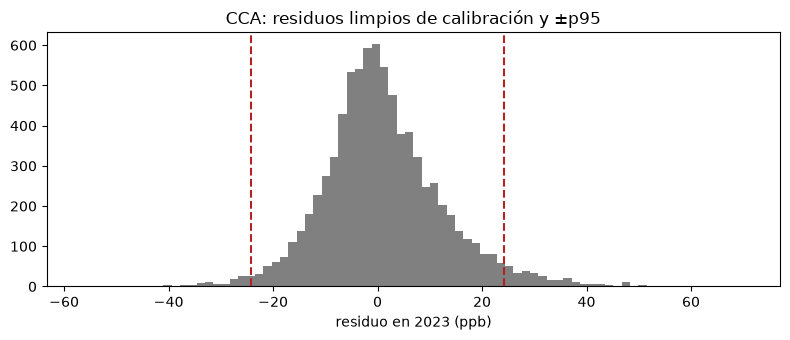

In [25]:
if res is not None and res['calibracion'] is not None:
    cal, u = res['calibracion'], res['umbral']
    met = em.metricas_limpias(cal, u)
    print(f"Umbral p95 de {REVISAR}: {u:.4f} ppb  (alerta si |residuo| > umbral)")
    print(pd.Series(met).round(3).to_string())
    mes = cal.assign(mes=cal.timestamp.dt.month, abs_res=cal.residuo_ppb.abs())
    r = cal.residuo_ppb
    print(f"RMSE LSTM {np.sqrt((r ** 2).mean()):.2f} ppb | RMSE solo perfil "
          f"{np.sqrt(((cal.original_ppb - cal.base_ppb) ** 2).mean()):.2f} ppb")
    sd = r.std(ddof=0)
    print(f"Dentro de ±1 sigma: {(r.abs() <= sd).mean():.1%} | dentro de ±2 sigma: {(r.abs() <= 2 * sd).mean():.1%}"
          f" | umbral = {u / sd:.2f} sigma")
    print('\nPor hora del día (sesgo + = el modelo subestima):')
    hora = cal.assign(hora=cal.timestamp.dt.hour, abs_res=cal.residuo_ppb.abs())
    print(hora.groupby('hora').agg(mae=('abs_res', 'mean'), sesgo=('residuo_ppb', 'mean'),
                                   sigma=('residuo_ppb', lambda x: x.std(ddof=0))).round(1).T.to_string())
    print('\nPor mes de 2023:')
    print(mes.groupby('mes').agg(n=('abs_res', 'size'), mae=('abs_res', 'mean'),
                                 p95_mes=('abs_res', lambda r: np.percentile(r, 95))).round(2).to_string())
    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.hist(cal.residuo_ppb, bins=80, color='0.5')
    for s in (-1, 1):
        ax.axvline(s * u, color='firebrick', ls='--')
    ax.set_xlabel('residuo en 2023 (ppb)'); ax.set_title(f'{REVISAR}: residuos limpios de calibración y ±p95')
    fig.tight_layout(); plt.show()
else:
    print('Sin calibración todavía.')

## 7. Reproducibilidad

El CLAUDE.md exige correr el mismo entrenamiento dos veces y confirmar que no
cambia. Con `VERIFICAR_REPRODUCIBILIDAD = True` se entrena el objetivo de nuevo
en `results/lstm_v4_multianual_v1/verificacion/<ESTACIÓN>/` (nunca encima del
original) y se comparan E, todos los pesos, el p95 y cada predicción.
Esperado: **todo `True`**. Si algo sale `False`, no aceptar resultados y avisar.

| Comprobación | Qué compara |
|---|---|
| `epoca_E` | Que la fase 1 elija la misma época en las dos corridas. |
| `pesos idénticos` | Los 7 arreglos de números del modelo (pesos y sesgos de LSTM y capas densas), valor por valor. |
| `umbral p95 idéntico` | El p95 de 2023 con todos sus decimales. |
| `calibracion_2023`, `predicciones_<año>` | Cada fila de cada archivo de predicciones. |

No se compara el hash del archivo `.keras`: puede cambiar por metadatos de guardado
aunque los pesos sean idénticos.

In [ ]:
# Corridas: CCA 2026-10-03 23:07 y TLI 23:53, ambas reproducibles (ver bitácora). Salida de abajo: TLI.
VERIFICAR_REPRODUCIBILIDAD = False   # ← True para reentrenar y comparar
OBJETIVO_VERIFICAR = 'TLI'

if VERIFICAR_REPRODUCIBILIDAD:
    if not (EST / OBJETIVO_VERIFICAR / 'modelo.keras').exists():
        raise FileNotFoundError('Primero entrena el original en la sección 4.')
    if not (VER / OBJETIVO_VERIFICAR / 'modelo.keras').exists():
        em.entrenar_objetivo(ctx, OBJETIVO_VERIFICAR, VER / OBJETIVO_VERIFICAR, verbose=0)
if (VER / OBJETIVO_VERIFICAR / 'modelo.keras').exists():
    comp = em.comparar_corridas(EST / OBJETIVO_VERIFICAR, VER / OBJETIVO_VERIFICAR)
    print(comp.to_string(index=False))
    print('\nREPRODUCIBLE:', bool(comp.identico.all()))
    if VERIFICAR_REPRODUCIBILIDAD:   # sólo se registra cuando se pidió la verificación
        em.registrar(BITACORA, 'verificar', OBJETIVO_VERIFICAR,
                     'reproducible' if comp.identico.all() else 'no_reproducible',
                     '; '.join(f'{r.comprobacion}={r.identico}' for r in comp.itertuples()),
                     flags=dict(VERIFICAR_REPRODUCIBILIDAD=True), carpeta=VER / OBJETIVO_VERIFICAR,
                     config=json.loads((VER / OBJETIVO_VERIFICAR / 'configuracion.json').read_text()))
else:
    print('Sin corrida de verificación todavía.')

Sin corrida de verificación todavía.


## 8. Evaluación limpia en prueba (2024, 2025, 2026)

> ⚠️ A partir de aquí se mira la prueba. El protocolo ya está congelado:
> lo que veas **no** puede usarse para cambiar épocas, umbrales, estaciones ni
> arquitectura. Si algo te hace querer cambiarlo, se registra como protocolo nuevo.

Las columnas son las mismas de la tabla de la sección 6 (ahí está de dónde sale
cada una). Resumen: `n` lecturas evaluadas; `mae` error absoluto
medio (ppb); `sesgo` media de `lectura − predicción` (positivo = el modelo
subestima); `sigma` dispersión del residuo; `falsas_alarmas` y `fpr` alertas
sobre lecturas limpias y su proporción (el p95 apuntaba a ≈5 % en 2023, pero en
otro año puede ser distinto); `*_solo_perfil` lo mismo sin LSTM.
2026 cubre sólo enero–julio: no compararlo como año completo.

In [27]:
EVALUAR_PRUEBA = False   # ← True sólo después de revisar las secciones 5–7

def tabla_limpia(objetivos):
    filas = []
    for obj in objetivos:
        r = em.cargar_objetivo(EST / obj)
        if r is None:
            continue
        for anio, pred in r['prueba'].items():
            filas.append(dict(objetivo=obj, anio=anio, clasificacion=clases.at[obj, 'clasificacion'],
                              umbral=r['umbral'], **em.metricas_limpias(pred, r['umbral'])))
    return pd.DataFrame(filas)

if EVALUAR_PRUEBA:
    limpias = tabla_limpia(m.ESTACIONES)
    if limpias.empty:
        print('No hay objetivos entrenados.')
    else:
        limpias.to_csv(SAL / 'metricas_limpias.csv', index=False)
        print(limpias.round(3).to_string(index=False))
        # Deja constancia de CUÁNDO y de QUÉ objetivos se miró la prueba (protocolo §2).
        em.registrar(BITACORA, 'evaluar_prueba', ' '.join(sorted(limpias.objetivo.unique())), 'mostrada',
                     'años: ' + ' '.join(map(str, sorted(limpias.anio.unique()))),
                     flags=dict(EVALUAR_PRUEBA=True))
else:
    print('EVALUAR_PRUEBA = False: no se muestran métricas de prueba.')

EVALUAR_PRUEBA = False: no se muestran métricas de prueba.


In [28]:
if EVALUAR_PRUEBA and (EST / REVISAR / 'configuracion.json').exists():
    r = em.cargar_objetivo(EST / REVISAR)
    for anio, pred in r['prueba'].items():
        p = pred.assign(mes=pred.timestamp.dt.month, hora=pred.timestamp.dt.hour,
                        abs_res=pred.residuo_ppb.abs(), alerta=pred.residuo_ppb.abs() > r['umbral'])
        print(f'\n{REVISAR} {anio} — por mes:')
        print(p.groupby('mes').agg(n=('abs_res', 'size'), mae=('abs_res', 'mean'),
                                   sesgo=('residuo_ppb', 'mean'), fpr=('alerta', 'mean')).round(3).to_string())
    pred = r['prueba'][2024]
    fig, ax = plt.subplots(figsize=(13, 4))
    tramo = pred[(pred.timestamp >= '2024-05-01') & (pred.timestamp < '2024-05-15')]
    ax.plot(tramo.timestamp, tramo.original_ppb, label='lectura', lw=1)
    ax.plot(tramo.timestamp, tramo.predicho_ppb, label='predicción LSTM', lw=1)
    ax.plot(tramo.timestamp, tramo.base_ppb, label='perfil 14 d', lw=0.8, ls=':')
    ax.axhline(155, color='firebrick', ls='--', lw=0.8, label='155 ppb')
    ax.set_title(f'{REVISAR}: 1–14 mayo 2024 (temporada alta), datos limpios'); ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

## 9. Registro de progreso y estado de los objetivos

Tres piezas, de la más automática a la más interpretativa:

1. **Bitácora automática** (`bitacora_entrenamiento.csv`): una fila por acción.
   Las filas con `origen_registro = reconstruido…` se agregaron a mano a partir de
   las fechas y archivos de corridas hechas antes de que existiera el registro.
2. **Estado de los 33 objetivos** (`estado_objetivos.csv`): se recalcula con lo
   que hay en disco cada vez que ejecutas esta sección.
3. **Notas escritas** (abajo): qué se decidió y cómo se interpretó. Agrega una
   entrada nueva por cada sesión; no edites las anteriores.

**Columnas de la bitácora:** `accion` y `resultado` (qué se hizo y cómo terminó);
los flags y `OBJETIVOS` vigentes en ese momento; `clasificacion` del objetivo;
`epoca_E`, `epocas_seleccion_ejecutadas`, `val_loss_minimo`, los `n_*` de cada
etapa y `umbral_p95_ppb` (ver tablas de las secciones 5 y 6); `segundos` de
duración; la configuración (`semilla`, `unidades`, `batch`, `max_epocas`,
`paciencia`, `shuffle`, `canales_inactivos`), versiones y hash del modelo.

**Columnas del estado:** `entrenado`, `verificado` (sí / no / DIFIERE),
`E_en_maximo` (True = E llegó a 60, el modelo quizá seguía mejorando),
`loss_final_fase2`, `umbral_p95`, `anios_prueba` con predicciones y, sobre 2023,
`mae_cal`, `sesgo_cal`, `sigma_cal`, `mae_perfil_cal` y `mejora_vs_perfil_pct`
(cuánto reduce el LSTM el MAE frente a usar sólo el perfil). No incluye métricas
de prueba: ésas están en la sección 8.

In [29]:
bit = em.leer_bitacora(BITACORA)
print(f'Bitácora: {len(bit)} filas')
if len(bit):
    print(bit[['fecha_hora', 'accion', 'objetivo', 'resultado', 'epoca_E', 'umbral_p95_ppb',
               'segundos', 'OBJETIVOS', 'origen_registro']].to_string(index=False))

Bitácora: 33 filas
               fecha_hora    accion objetivo         resultado epoca_E     umbral_p95_ppb segundos                                                                                                                   OBJETIVOS                                                               origen_registro
2026-10-03T23:00:06-06:00  entrenar      CCA         entrenado       2 24.155933690922595                                                                                                                                  CCA reconstruido 2026-10-03 desde fechas de archivos (corrida previa al registro)
2026-10-03T23:07:45-06:00 verificar      CCA      reproducible       2 24.155933690922595                                                                                                                                      reconstruido 2026-10-03 desde fechas de archivos (corrida previa al registro)
2026-10-03T23:30:09-06:00  entrenar      ACO         entrenado      11  20.609

In [30]:
estado = em.estado_objetivos(EST, VER, clases)
estado.to_csv(SAL / 'estado_objetivos.csv', index=False)
print(f"Entrenados: {int(estado.entrenado.sum())}/{len(estado)} | "
      f"elegibles sin entrenar: {[o for o in ELEGIBLES if not estado.set_index('objetivo').at[o, 'entrenado']]}")
print(estado.to_string(index=False))

Entrenados: 31/33 | elegibles sin entrenar: []
objetivo          clasificacion                                     motivo  entrenado verificado  epoca_E  epocas_fase1 E_en_maximo  val_loss_min  loss_final_fase2  n_ajuste_def  n_calibracion  umbral_p95   anios_prueba  mae_cal  sesgo_cal  sigma_cal  mae_perfil_cal  mejora_vs_perfil_pct
     ACO              principal                                        NaN       True         no     11.0          19.0       False         94.67             33.30       13412.0         6745.0      20.610      2025 2026     7.35      -1.50       9.85            8.40                  12.5
     AJM baja_representatividad     ajuste_inicial: 2489 ejemplos, 4 meses       True         no     23.0          31.0       False        212.36             47.98        7168.0         6931.0      32.514 2024 2025 2026    12.51       3.59      15.75           12.50                  -0.1
     AJU              principal                                        NaN       True 

### Notas escritas (bitácora narrativa)

#### 2026-10-03 — Prueba técnica con CCA

- **Qué se hizo:** `ENTRENAR = True`, `OBJETIVOS = ['CCA']` (22:59–23:00);
  después `VERIFICAR_REPRODUCIBILIDAD = True` sobre CCA (23:07). No se miró la prueba.
- **Resultado del entrenamiento:** E = 2; la fase 1 ejecutó 10 épocas (2 + 8 de
  paciencia). `val_loss` mínimo 154.0 ppb² (≈12.4 ppb) en la época 2; luego
  osciló entre 162 y 166 mientras `loss` siguió bajando de 162 a 53.
- **Calibración 2023:** p95 = 24.1559 ppb; MAE 8.59 ppb frente a 10.67 con sólo
  el perfil (−19 %); RMSE 11.68 frente a 14.78; sesgo +1.08; sigma 11.63 (74 %
  dentro de ±1 sigma, 94 % dentro de ±2); FPR 0.05 por construcción.
- **Reproducibilidad:** dos corridas independientes idénticas (E, 7 arreglos de
  pesos, p95 y todas las predicciones). Inferencia tras cargar de disco igual a lo
  guardado (diferencia ≤ 1.4e-14 ppb por escritura del CSV).
- **Interpretación:**
  - El LSTM sí mejora al perfil de 14 días.
  - El sesgo global ≈ 0 oculta un patrón horario: +6 a +8 ppb entre 12 y 16 h
    (subestima justo en la franja de contingencias) y −2.5 en la madrugada; sigma
    va de 4.6 ppb (7 h) a 17.6 ppb (14 h).
  - E = 2 indica que lo generalizable se aprende muy rápido y que después el modelo
    memoriza 2020–2021 (deriva entre años). Es una señal de sensibilidad de la
    selección, no un error.
- **Decisiones:** no se cambia nada del protocolo (cambiarlo sería otra versión,
  decidida sin ver la prueba). CCA queda **aceptado como prueba técnica**.
  Siguiente: entrenar los 30 elegibles restantes y verificar un segundo objetivo.

#### 2026-10-03 — Entrenamiento de los 30 elegibles restantes y verificación de TLI

- **Qué se hizo:** `ENTRENAR = True`, `OBJETIVOS = ELEGIBLES`, `VERBOSE = 1`
  (23:30–23:49, ≈19 min). CCA se saltó por existir. Después
  `VERIFICAR_REPRODUCIBILIDAD = True`, `OBJETIVO_VERIFICAR = 'TLI'` (23:53, 17 s
  de entrenamiento). No se miró la prueba (`EVALUAR_PRUEBA = False`).
- **Resultado:** 30 entrenados, 0 errores. HGM y XAL quedan fuera (no están en
  `ELEGIBLES`; motivo en `estado_objetivos.csv`). Ningún E llegó a 60:
  E = 1 en 4 objetivos, 2 en 11, 3–5 en 8, 6–11 en 6 y 23 en AJM.
  p95 entre 18.9 y 32.5 ppb (mediana 22.4).
- **Calibración 2023:** el LSTM reduce el MAE frente al perfil en 29 de 30
  objetivos (mediana −15.9 %; máximo NEZ −24.8 % y MGH −24.5 %). Sesgo entre 12 y
  16 h con mediana +3.0 ppb (−3.0 a +7.9) y sigma de la tarde con mediana 15.4 ppb;
  madrugada −1.7. El patrón horario de CCA se repite en la red.
- **Casos a reportar aparte:** AJM (baja representatividad, ajuste inicial de 4
  meses) **no mejora al perfil** (−0.1 %), tiene el p95 más alto (32.5) y E = 23.
  INN (baja representatividad) mejora sólo 3.4 %. FAR, MPA y AJU mejoran entre 6.5
  y 9.7 %. TLI (baja representatividad por calibración) mejora 12.8 %.
- **Reproducibilidad:** TLI idéntico en E (2), 7 arreglos de pesos, p95
  (21.16388045719691) y predicciones de 2023–2026. Ya hay 2 objetivos verificados
  (CCA y TLI).
- **Decisiones:** no se cambia nada del protocolo. Las predicciones
  (`calibracion_2023`, `predicciones_*`) quedan fuera de git porque se regeneran
  exactamente desde cada modelo; se versionan modelos, umbrales, configuraciones,
  historias, bitácora y estado. Siguiente: notebook 13 (ataques y daño), cargando
  estos modelos.

#### Plantilla para la siguiente entrada

```
#### AAAA-MM-DD — título
- Qué se hizo (flags, OBJETIVOS, horas):
- Resultado (E, p95, métricas de 2023, verificación):
- Interpretación:
- Decisiones / pendientes:
```

## 10. Qué sigue

- Si CCA entrenó bien (curvas razonables, E < 60, reproducible) y lo aceptas,
  entrena el resto con `OBJETIVOS = ELEGIBLES` (sección 4) y verifica la
  reproducibilidad de al menos otro objetivo además de CCA.
- Las secciones del protocolo que **no** están en este libro: ataques pareados
  al 5 % y barrido de bits 0–7 (§7.2–7.3), daño local y de red con 155 ppb (§8),
  diagnóstico de estaciones (§9) y CNN-1D. Irán en un libro aparte que **carga**
  estos modelos, sin reentrenarlos.
- Al reportar cualquier número, aclarar que viene de modelos de
  `results/lstm_v4_multianual_v1/estaciones/` entrenados con este protocolo.